<h2>Approximations for MAX-SAT</h2>
We will start by examining a very elegant approximation algorithm for the MAX-SAT problem. The key idea here is to use a probabilistic argument initially but we will get rid of all randomness in the end (the technical term for this is called de-randomization) so that we are left with a purely deterministic algorithm.

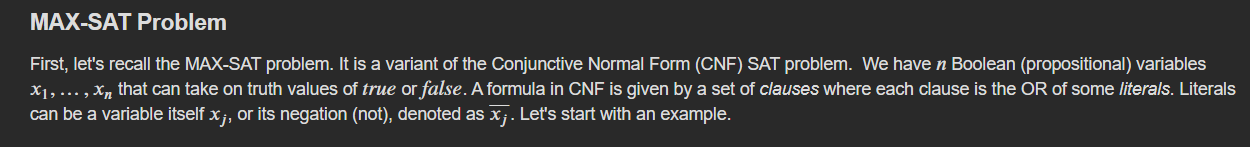

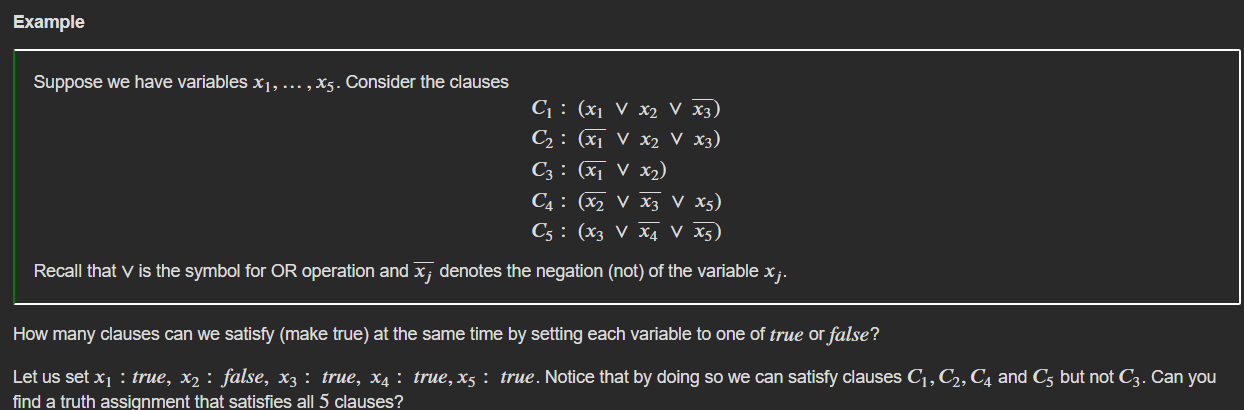

The MAX-SAT problem asks given a set of variables  𝑥1,…,𝑥𝑛 and CNF clauses  𝐶1,…,𝐶𝑚 a truth assignment to  𝑥1,…,𝑥𝑛 that satisfies the maximum number of clauses. I.e, no other truth assignment can satisfy a strictly greater number of clauses.

We could evaluate all possible situations by setting each variable to false or true but this is exponential solution 2<sup>n</sup>. It is easy to see that MAX-SAT is NP-hard because if we can solve MAX-SAT efficiently, we can use our solution in a simple manner to check if a Boolean formula given as CNF is satisfiable ( we use MAX-SAT to find if there is assignment that could satisfy all given clauses). We know that CNF Satisfiability problem is NP-Complete.

We take help of approximation/ greedy algorithm to reduce the number of possibilities and still get approximate optimal solution.

<h3>Approximation Algorithm for MAX-3-SAT</h3>

We will consider the special case of MAX-3-SAT when each clause has precisely three literals. Also assume that all the literals in a clause are distinct.

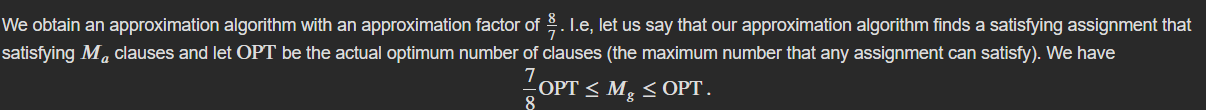

If you are noticing that this inequality seems different from what we saw from the vertex cover or job-shop scheduling problems, note that in those problems we were minimizing an objective (the makespan or the size of the vertex cover). Here we are maximizing the number of satisfied clauses.

We will now derive the approximation algorithm in <u>two phases</u>:

1. We will <u>show that a random choice of  true/false for each variable</u> will satisfy  7/8  ths of the clauses on average.
2. We will proceed to remove all randomness and force the algorithm to discover an "above average" truth assignment that is guaranteed to satisfy at least  7/8 ths the total number of clauses in the problem. However, the  OPT
  cannot exceed the total number of clauses in the first place. Therefore, the approximation ratio described above will follow.

<h4>Randomized Truth Assignment</h4>
Let's just say that we assign each variable  𝑥𝑖 to be  true with probability  1/2 and  false with probability  1/2
 , by tossing an unbiased coin. We assume that the toss for each variable  𝑥𝑖 is independent of previous tosses of the coin for the other variables.

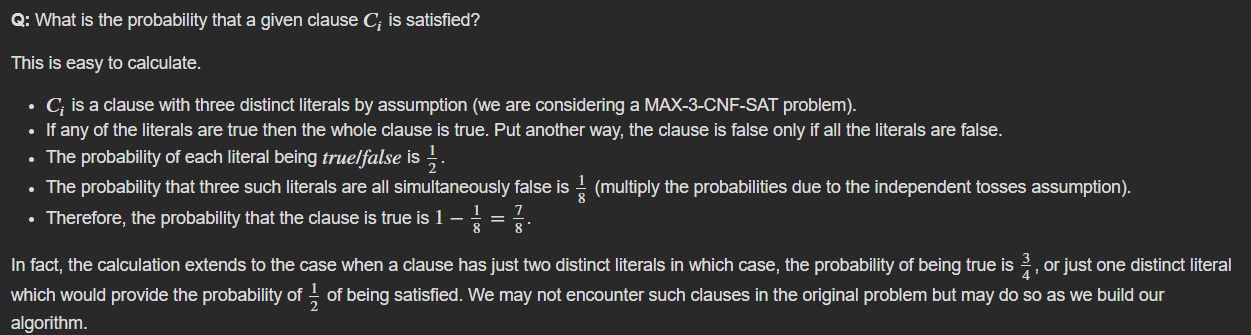


Indicator variable based analysis

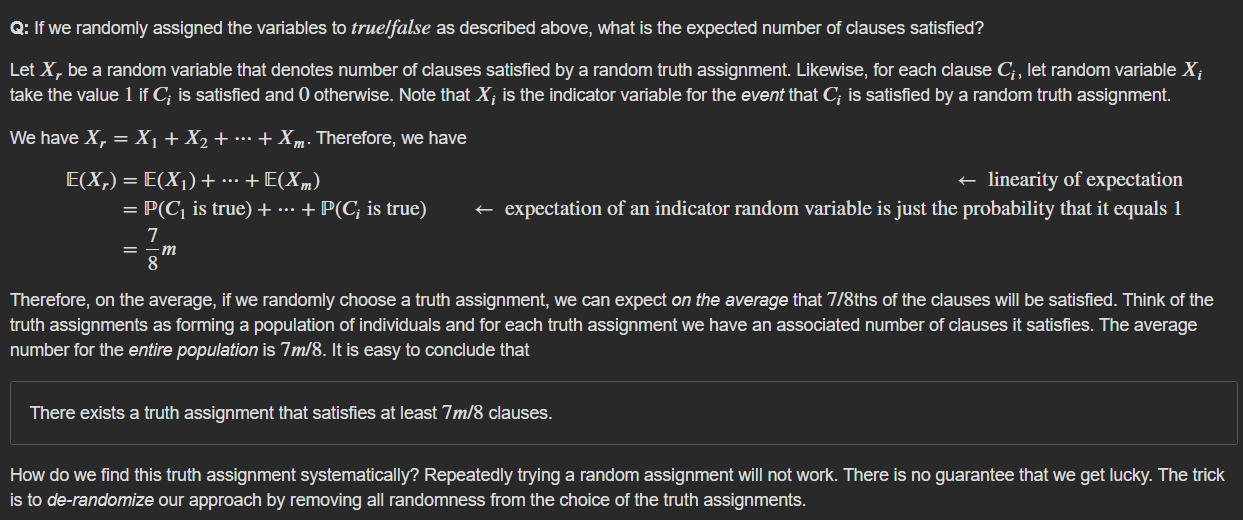

<h2>De-Randomized Approximation Algorithm</h2>
The basic idea is to consider the variables  𝑥1,…,𝑥𝑛 , one at a time. Let's start with  𝑥1. We can separately consider two cases by setting  𝑥1 true and  false, respectively. For each case, when we plug in a truth value of  𝑥1, the formula can be simplified. 

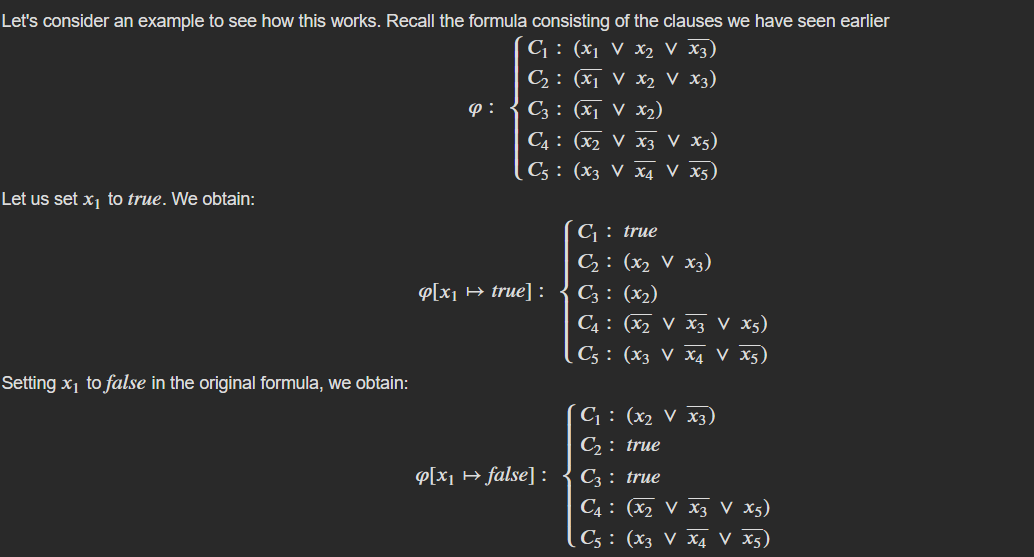
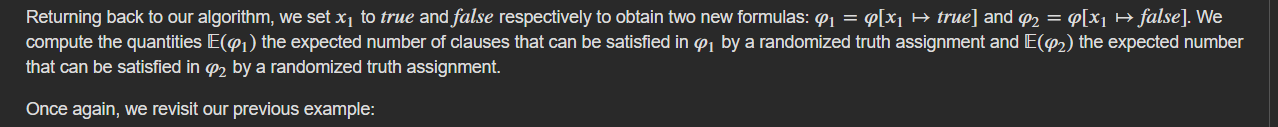
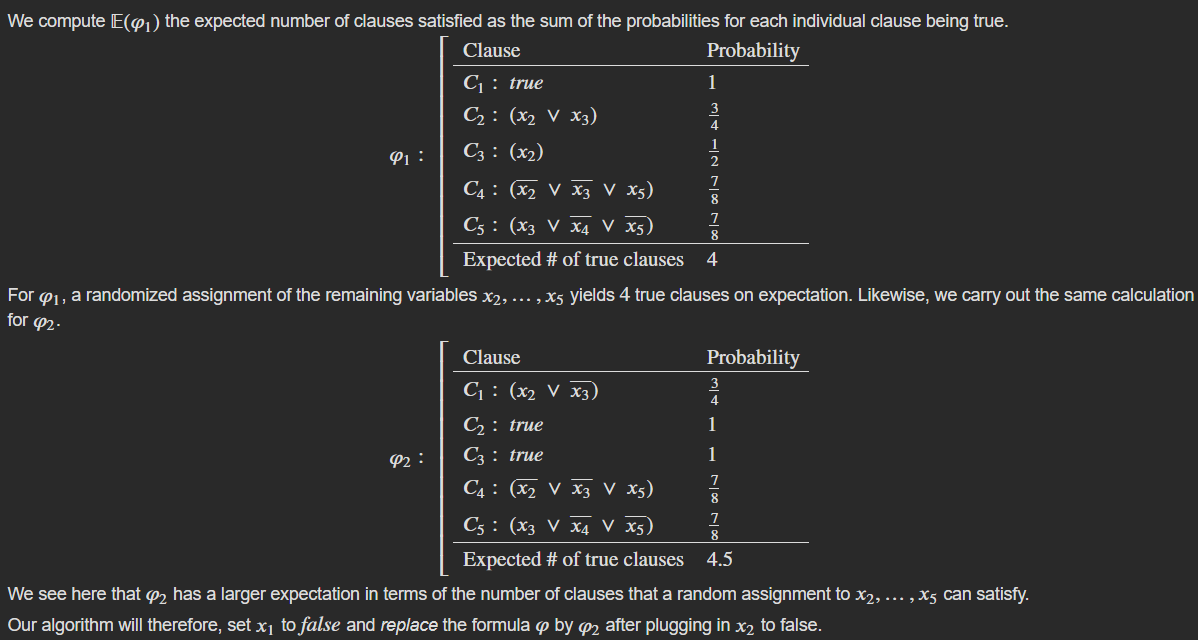
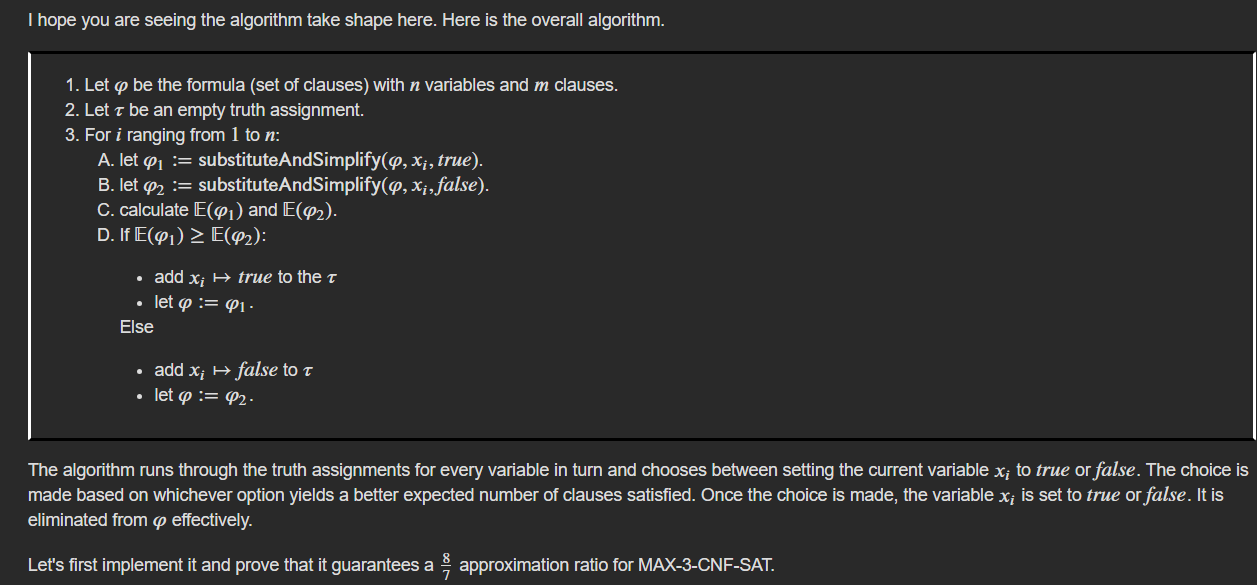





In [1]:
# We will represent clause as a list of literals, 
# A -ve sign in front of the literal means that the 
# corresponding variable is negated.
# Eg., (x2 or not x4 or x5) --> [2, -4, 5]
# IMPORTANT: we assume clauses are not empty and a variable cannot appear twice in the same clause.

# given a list of clauses and a truth assignment as a list of true/false, return number of clauses satisfied
def num_clauses_satisfied(lst_of_clauses, truth_assign):   
    # truth_assign is simply a list of booleans. 
    # The truth assignment for variable # i is given by truth_assign[i-1]
    n = len(truth_assign)
    m = len(lst_of_clauses)
    num_satisfied = 0
    for clause in lst_of_clauses:
        is_clause_satisfied = any([truth_assign[j-1] if j > 0 else not truth_assign[-j-1] for j in clause])
        num_satisfied += 1 if is_clause_satisfied else 0
    return num_satisfied

# Given a list of clauses, calculate the expectation
# Assume that the same variable does not repeat in a given clause.
# This calculation will be incorrect if this assumption does not hold
def expectation(lst_of_clauses):
    expect = 0
    for clause in lst_of_clauses: # go through the clauses
        expect += 1.0 - 1.0/(2.0**len(clause)) # add to the expectation based on the probability clause is true.
    return expect

# Assign and Simplify the clause by assigning variable var to boolean value val
def assign_and_simplify(lst_of_clauses, var, val):
    new_list_of_clauses = []
    num_satisfied = 0 # counter for number of clauses we satisfy due to this assignment
    num_falsified = 0 # counter for number of clauses we falsify due to this assignment
    for clause in lst_of_clauses: # go through each clause
        var_in_clause = var in clause # is the variable `var` part of our clause
        neg_var_in_clause = (-var) in clause #is the literate not (var) part of our clause
        if (var_in_clause and val) or (neg_var_in_clause and not val):
                # entire clause is true
                num_satisfied += 1
        elif (var_in_clause and not val) or (neg_var_in_clause and val):
                # remove var from clause 
                new_clause = [j for j in clause if (j != var and j != -var)]
                if len(new_clause) == 0: # did the clause become empty as a result?
                    num_falsified += 1
                else:
                    new_list_of_clauses.append(new_clause) # append new clause
        else:
            new_list_of_clauses.append(clause)
    
    assert len(lst_of_clauses) ==len(new_list_of_clauses) + num_satisfied + num_falsified 
    return (num_satisfied, num_falsified, new_list_of_clauses)

def approx_max_sat(n, lst_of_clauses):
    # make sure that the clauses hae literals -i or i for i in range 1 to n inclusive
    assert all( all( 1 <= lj <= n or -n <= lj <= -1 for lj in clause) for clause in lst_of_clauses)
    clauses = lst_of_clauses
    assign = []
    num_sat = 0
    num_fals = 0
    for i in range(1, n+1): # go through each variable 
        (n1, f1, phi1) = assign_and_simplify(clauses, i, True) # create formula by assigning xi -> True
        (n2, f2, phi2) = assign_and_simplify(clauses, i, False)# xi -> False
        e1 = expectation(phi1) + n1  # calculate expectations but also account for number of satisfied clauses
        e2 = expectation(phi2) + n2
        if (e1 >= e2): 
            assign.append(True) # assign xi to true
            num_sat += n1
            num_fals += f1
            clauses = phi1 # replace the formula with phi1
        else:
            assign.append(False) # assign xi to false
            num_sat += n2
            num_fals += f2
            clauses = phi2 # replace the forumula with phi2
    return (assign, num_sat)
            
    

In [2]:
## TEST

n = 5
lst_of_clauses = [
    [1, 3, -4],
    [2, -3, -5],
    [-1, -2, -4],
    [1, -2],
    [-1, 3, -5],
    [4, 5]
]

print(expectation(lst_of_clauses))
(n1, f1, c1) = assign_and_simplify(lst_of_clauses, 3, False)
print(f'{n1}, {f1}')
print(c1)
#approx_max_sat(n, lst_of_clauses)
assign, num_clauses = approx_max_sat(n, lst_of_clauses)
print(f'Found assignment satisfying {num_clauses} clauses.')
for i in range(n):
    print(f'x_{i+1} --> {assign[i]}')

#print(num_clauses_satisfied(lst_of_clauses, assign))

5.0
1, 0
[[1, -4], [-1, -2, -4], [1, -2], [-1, -5], [4, 5]]
Found assignment satisfying 6 clauses.
x_1 --> True
x_2 --> False
x_3 --> True
x_4 --> True
x_5 --> False


In [3]:
## TEST
n = 9
lst_of_clauses = [
    [1, 4, -7],
    [-1, -3, -8],
    [2, 5, -7],
    [-2, -6, -9],
    [1, -4, -7],
    [-1, 4, 5],
    [4, 6, 9],
    [-7, -8, 9],
    [8, 9],
    [-9],
    [-8],
    [-6]
]
assign, num_clauses = approx_max_sat(n, lst_of_clauses)
print(f'Found assignment satisfying {num_clauses} clauses.')
for i in range(n):
    print(f'x_{i+1} --> {assign[i]}')

#print(num_clauses_satisfied(lst_of_clauses, assign))

Found assignment satisfying 11 clauses.
x_1 --> True
x_2 --> True
x_3 --> False
x_4 --> True
x_5 --> True
x_6 --> False
x_7 --> False
x_8 --> False
x_9 --> True


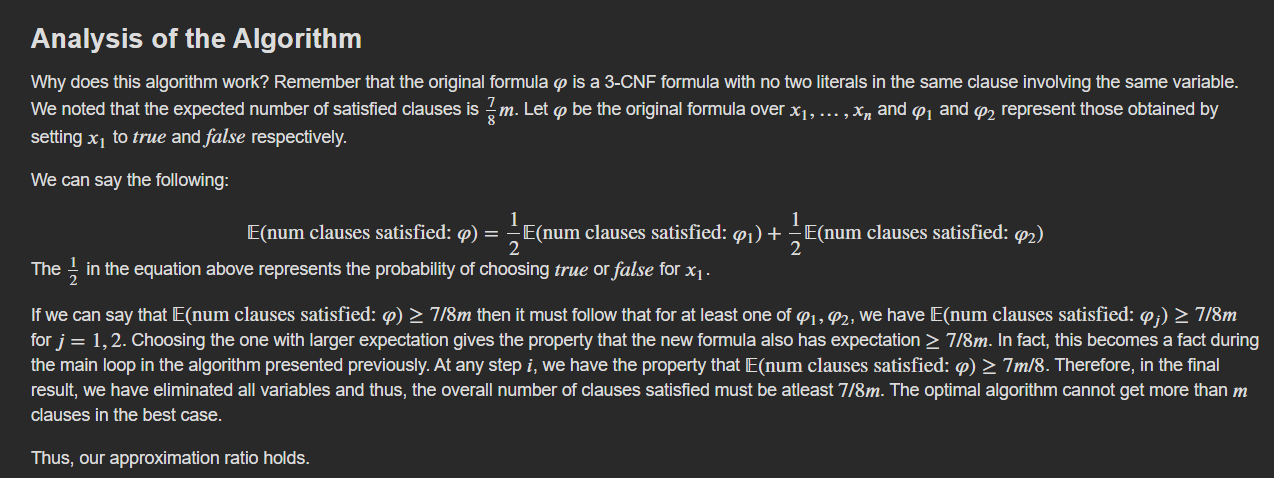